In [20]:
if semantic_overlaps:
    # Convert to DataFrame
    overlap_df = pd.DataFrame(semantic_overlaps, 
                              columns=['phrase_1', 'category_1', 'phrase_2', 'category_2', 'similarity'])
    overlap_df = overlap_df.sort_values('similarity', ascending=False)
    
    # Save to CSV
    output_file = 'results/phase i/11b_candidate_phrase_overlaps.csv'
    overlap_df.to_csv(output_file, index=False)
    print(f"✓ Saved {len(overlap_df)} semantic overlaps to: {output_file}")
    
    # Show sample
    print(f"\nSample (top 5):")
    print(overlap_df.head().to_string(index=False))
else:
    print("No overlaps to export.")

✓ Saved 36 semantic overlaps to: results/phase i/11b_candidate_phrase_overlaps.csv

Sample (top 5):
                           phrase_1 category_1                           phrase_2    category_2  similarity
         data anonymization failure    IT/Data        Data anonymization failures     Processes    0.958879
         data backup system failure    IT/Data        Data backup process failure     Processes    0.956563
Spokesperson inappropriate comments  Personnel Inappropriate spokesperson comment Communication    0.938125
          Export control violations  Processes           Export control violation         Legal    0.936801
   Unethical treatment of employees Governance         Unethical employee conduct     Personnel    0.922811


## 5. Export Overlap Details (Optional)

Export semantic overlaps to CSV for manual review if needed.

In [19]:
print("=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)

print(f"\nTotal candidate phrases: {sum(len(p) for p in phrase_dict.values())}")
print(f"Categories: {len(phrase_dict)}")

print(f"\n1. EXACT OVERLAPS:")
if exact_overlaps:
    print(f"   ⚠️  {len(exact_overlaps)} exact duplicate phrases found across categories")
    print(f"   → ACTION REQUIRED: Review and remove duplicates")
else:
    print(f"   ✓ No exact overlaps")

print(f"\n2. SEMANTIC OVERLAPS (≥{SIMILARITY_THRESHOLD}):")
if semantic_overlaps:
    print(f"   ⚠️  {len(semantic_overlaps)} phrase pairs with high semantic similarity")
    print(f"   → ACTION: Review top overlaps and consider removal or reassignment")
    
    # Count overlaps by category pair
    overlap_counts = defaultdict(int)
    for _, cat1, _, cat2, _ in semantic_overlaps:
        pair = tuple(sorted([cat1, cat2]))
        overlap_counts[pair] += 1
    
    print(f"\n   Top category pairs with overlaps:")
    for pair, count in sorted(overlap_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"     {pair[0]} ↔ {pair[1]}: {count} overlaps")
else:
    print(f"   ✓ No high semantic overlaps")

print(f"\n3. CATEGORY SEPARATION:")
avg_cross_sim = avg_sim_matrix[off_diag_mask].mean()
if avg_cross_sim < 0.5:
    print(f"   ✓ Good separation (avg cross-category similarity: {avg_cross_sim:.3f})")
elif avg_cross_sim < 0.7:
    print(f"   ⚠️  Moderate separation (avg cross-category similarity: {avg_cross_sim:.3f})")
else:
    print(f"   ❌ Poor separation (avg cross-category similarity: {avg_cross_sim:.3f})")

print("\n" + "=" * 80)
if not exact_overlaps and not semantic_overlaps:
    print("✅ VALIDATION PASSED: Candidate phrases are clean!")
    print("=" * 80)
    print("\nYou can proceed to notebook 12 (semantic similarity calculation).")
else:
    print("⚠️  REVIEW REQUIRED: Overlaps detected")
    print("=" * 80)
    print("\nRecommendations:")
    if exact_overlaps:
        print("  1. Remove exact duplicate phrases or assign to single category")
    if semantic_overlaps:
        print("  2. Review high-similarity pairs and remove/reassign as needed")
    print("  3. Re-run this validation after making changes")
    print("  4. Consider lowering similarity threshold in notebook 12 if needed")

VALIDATION SUMMARY

Total candidate phrases: 1400
Categories: 7

1. EXACT OVERLAPS:
   ✓ No exact overlaps

2. SEMANTIC OVERLAPS (≥0.85):
   ⚠️  36 phrase pairs with high semantic similarity
   → ACTION: Review top overlaps and consider removal or reassignment

   Top category pairs with overlaps:
     Governance ↔ Personnel: 14 overlaps
     Communication ↔ Personnel: 7 overlaps
     IT/Data ↔ Processes: 4 overlaps
     IT/Data ↔ Products: 3 overlaps
     Legal ↔ Processes: 2 overlaps

3. CATEGORY SEPARATION:
   ✓ Good separation (avg cross-category similarity: 0.469)

⚠️  REVIEW REQUIRED: Overlaps detected

Recommendations:
  2. Review high-similarity pairs and remove/reassign as needed
  3. Re-run this validation after making changes
  4. Consider lowering similarity threshold in notebook 12 if needed


## 4. Summary Report

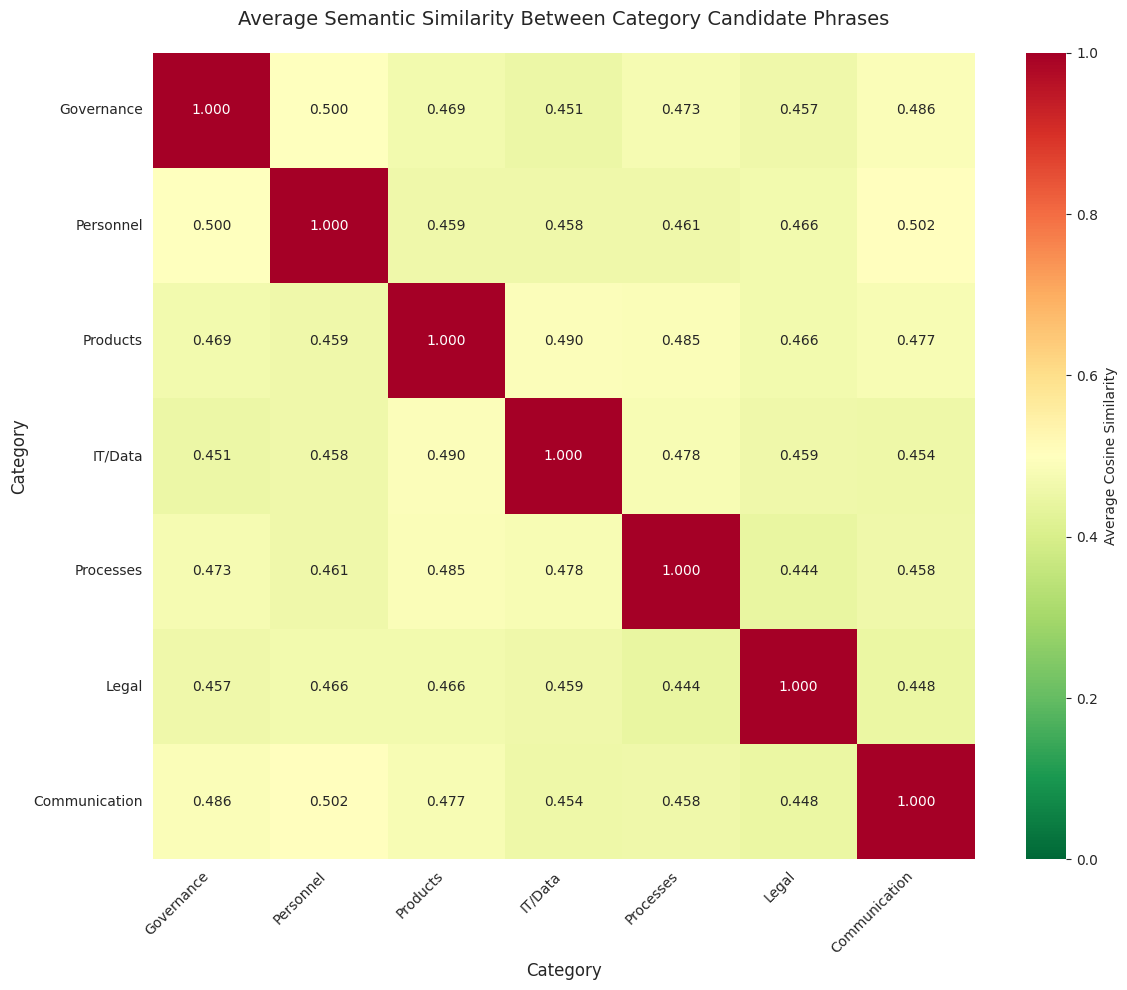


Average off-diagonal similarity (cross-category):
  Mean: 0.469
  Max:  0.502
  Min:  0.444


In [18]:
# Compute average similarity matrix between categories
categories = list(phrase_dict.keys())
n_cats = len(categories)
avg_sim_matrix = np.zeros((n_cats, n_cats))

for i, cat1 in enumerate(categories):
    for j, cat2 in enumerate(categories):
        if i == j:
            avg_sim_matrix[i, j] = 1.0  # Perfect self-similarity
        elif i < j:
            # Compute average cosine similarity
            similarities = util.cos_sim(embeddings_dict[cat1], embeddings_dict[cat2])
            avg_sim = similarities.mean().item()
            avg_sim_matrix[i, j] = avg_sim
            avg_sim_matrix[j, i] = avg_sim  # Symmetric

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(avg_sim_matrix, 
            xticklabels=categories, 
            yticklabels=categories,
            annot=True, 
            fmt='.3f',
            cmap='RdYlGn_r',  # Red=high similarity, Green=low
            vmin=0, 
            vmax=1,
            cbar_kws={'label': 'Average Cosine Similarity'})

plt.title('Average Semantic Similarity Between Category Candidate Phrases', fontsize=14, pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nAverage off-diagonal similarity (cross-category):")
off_diag_mask = ~np.eye(n_cats, dtype=bool)
print(f"  Mean: {avg_sim_matrix[off_diag_mask].mean():.3f}")
print(f"  Max:  {avg_sim_matrix[off_diag_mask].max():.3f}")
print(f"  Min:  {avg_sim_matrix[off_diag_mask].min():.3f}")

## 3. Similarity Heatmap

Visualize average semantic similarity between categories.

In [17]:
def find_semantic_overlaps(phrase_dict, embeddings_dict, threshold=0.85):
    """
    Find phrases with high semantic similarity across different categories.
    Returns: list of (phrase1, cat1, phrase2, cat2, similarity)
    """
    overlaps = []
    categories = list(phrase_dict.keys())
    
    # Compare each pair of categories
    for i, cat1 in enumerate(categories):
        for cat2 in categories[i+1:]:  # Only compare each pair once
            # Compute cosine similarities between all phrases in cat1 and cat2
            similarities = util.cos_sim(embeddings_dict[cat1], embeddings_dict[cat2])
            
            # Find pairs above threshold
            high_sim_indices = torch.where(similarities >= threshold)
            
            for idx1, idx2 in zip(high_sim_indices[0].tolist(), high_sim_indices[1].tolist()):
                phrase1 = phrase_dict[cat1][idx1]
                phrase2 = phrase_dict[cat2][idx2]
                sim_score = similarities[idx1, idx2].item()
                overlaps.append((phrase1, cat1, phrase2, cat2, sim_score))
    
    return overlaps


# Find semantic overlaps
print(f"\nSearching for semantic overlaps (threshold={SIMILARITY_THRESHOLD})...")
semantic_overlaps = find_semantic_overlaps(phrase_dict, embeddings_dict, SIMILARITY_THRESHOLD)

print("=" * 80)
print("SEMANTIC OVERLAP ANALYSIS")
print("=" * 80)

if semantic_overlaps:
    print(f"\n⚠️  Found {len(semantic_overlaps)} semantic overlaps (similarity ≥ {SIMILARITY_THRESHOLD}):\n")
    
    # Sort by similarity (highest first)
    semantic_overlaps.sort(key=lambda x: x[4], reverse=True)
    
    for phrase1, cat1, phrase2, cat2, sim in semantic_overlaps[:20]:  # Show top 20
        print(f"  Similarity: {sim:.3f}")
        print(f"    '{phrase1}' ({cat1})")
        print(f"    '{phrase2}' ({cat2})\n")
    
    if len(semantic_overlaps) > 20:
        print(f"  ... and {len(semantic_overlaps) - 20} more\n")
else:
    print(f"\n✓ No semantic overlaps found above {SIMILARITY_THRESHOLD}!")


Searching for semantic overlaps (threshold=0.85)...
SEMANTIC OVERLAP ANALYSIS

⚠️  Found 36 semantic overlaps (similarity ≥ 0.85):

  Similarity: 0.959
    'data anonymization failure' (IT/Data)
    'Data anonymization failures' (Processes)

  Similarity: 0.957
    'data backup system failure' (IT/Data)
    'Data backup process failure' (Processes)

  Similarity: 0.938
    'Spokesperson inappropriate comments' (Personnel)
    'Inappropriate spokesperson comment' (Communication)

  Similarity: 0.937
    'Export control violations' (Processes)
    'Export control violation' (Legal)

  Similarity: 0.923
    'Unethical treatment of employees' (Governance)
    'Unethical employee conduct' (Personnel)

  Similarity: 0.907
    'Unethical treatment of employees' (Governance)
    'Unethical employee actions' (Personnel)

  Similarity: 0.904
    'Unethical organizational behavior' (Governance)
    'Unethical employee conduct' (Personnel)

  Similarity: 0.899
    'CEO inappropriate statements' (

In [16]:
# Encode all phrases by category
print("Encoding phrases...")
embeddings_dict = {}
for category, phrases in phrase_dict.items():
    print(f"  {category}: {len(phrases)} phrases")
    embeddings = model.encode(phrases, convert_to_tensor=True)
    embeddings_dict[category] = embeddings

print("✓ Encoding complete")

Encoding phrases...
  Governance: 200 phrases
  Personnel: 200 phrases
  Products: 200 phrases
  IT/Data: 200 phrases
  Processes: 200 phrases
  Legal: 200 phrases
  Communication: 200 phrases
✓ Encoding complete


In [15]:
# Load embedding model
print(f"Loading model: {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME)
print("✓ Model loaded")

Loading model: BAAI/bge-m3...
✓ Model loaded


## 2. Semantic Overlap Detection

This section uses BGE-M3 embeddings to find phrases that are semantically similar across different categories.

In [14]:
def find_exact_overlaps(phrase_dict):
    """
    Find phrases that appear in multiple categories (exact match, case-insensitive).
    Returns: {phrase: [category1, category2, ...]}
    """
    phrase_to_categories = defaultdict(list)
    
    for category, phrases in phrase_dict.items():
        for phrase in phrases:
            phrase_lower = phrase.lower().strip()
            phrase_to_categories[phrase_lower].append(category)
    
    # Filter to only overlapping phrases
    overlaps = {phrase: cats for phrase, cats in phrase_to_categories.items() 
                if len(cats) > 1}
    
    return overlaps


# Find exact overlaps
exact_overlaps = find_exact_overlaps(phrase_dict)

print("=" * 80)
print("EXACT OVERLAP ANALYSIS")
print("=" * 80)

if exact_overlaps:
    print(f"\n⚠️  Found {len(exact_overlaps)} exact overlaps:\n")
    for phrase, categories in sorted(exact_overlaps.items()):
        print(f"  '{phrase}'")
        print(f"    → Categories: {', '.join(categories)}\n")
else:
    print("\n✓ No exact overlaps found!")

EXACT OVERLAP ANALYSIS

✓ No exact overlaps found!


## 1. Exact Overlap Detection

In [13]:
# Load candidate phrases
df = pd.read_csv(CANDIDATE_PHRASES_PATH)

# Organize by category
phrase_dict = {}
for category in df['category'].unique():
    phrases = df[df['category'] == category]['candidate_phrase'].tolist()
    phrase_dict[category] = phrases

print("=" * 80)
print("CANDIDATE PHRASES LOADED")
print("=" * 80)
print(f"\nCategories: {list(phrase_dict.keys())}")
print(f"\nPhrase counts per category:")
for cat, phrases in phrase_dict.items():
    print(f"  {cat:20s}: {len(phrases):3d} phrases")

print(f"\nTotal phrases: {sum(len(phrases) for phrases in phrase_dict.values())}")

CANDIDATE PHRASES LOADED

Categories: ['Governance', 'Personnel', 'Products', 'IT/Data', 'Processes', 'Legal', 'Communication']

Phrase counts per category:
  Governance          : 200 phrases
  Personnel           : 200 phrases
  Products            : 200 phrases
  IT/Data             : 200 phrases
  Processes           : 200 phrases
  Legal               : 200 phrases
  Communication       : 200 phrases

Total phrases: 1400


## Load Candidate Phrases

In [12]:
# File path
CANDIDATE_PHRASES_PATH = 'results/phase i/11_candidate_phrases_v4.csv'  # v4 with enhanced boundary-aware prompts

# Semantic similarity threshold
SIMILARITY_THRESHOLD = 0.85  # Phrases above this threshold are considered too similar

# Model for semantic similarity
MODEL_NAME = 'BAAI/bge-m3'  # Same model used in pipeline

print(f"Candidate phrases path: {CANDIDATE_PHRASES_PATH}")
print(f"Similarity threshold: {SIMILARITY_THRESHOLD}")
print(f"Model: {MODEL_NAME}")

Candidate phrases path: results/phase i/11_candidate_phrases_v4.csv
Similarity threshold: 0.85
Model: BAAI/bge-m3


## Configuration

In [11]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
import torch

# Setup plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("✓ Libraries loaded")

✓ Libraries loaded


## Setup

# Candidate Phrases Validation: Overlap Detection

**Purpose**: Validate candidate phrases from `11_candidate_phrases_v3.csv` for overlaps before proceeding to notebook 12.

**What this notebook does:**
1. Load candidate phrases (1,402 phrases across 7 categories)
2. Detect exact phrase overlaps between categories
3. Detect semantic similarity overlaps using BGE-M3 embeddings
4. Generate comprehensive overlap report with recommendations

**Why this matters:**
- Overlapping candidate phrases → confusion during classification
- Clean candidates = clearer category boundaries
- Catch issues before semantic similarity calculations in notebook 12